In [1]:
import icechunk
import xarray

# Working with the AHN DSM virtual Zarr store

This notebook shows how to open a virtual Zarr store for the high-resolution (7.5 cm) Digital Surface Model (DSM) derived from the Actueel Hoogtebestand Nederland (AHN), version 4.

The virtual Zarr store is made available via the SURF object store, in three different formats:
* a JSON kerchunk reference file;
* a Parquet kerchunk reference file;
* an Icechunk repository.

## Open the kerchunk reference files

Opening the JSON reference file:

In [2]:
ds = xarray.open_dataset(
    "https://objectstore.surf.nl/cloud-nes-benchmarks/ahn/4/DSM05/refs-COG-400-LZW.json", 
    engine="kerchunk"
)
ds

<xarray.Dataset> Size: 1GB
Dimensions:  (y: 16000, x: 16000)
Coordinates:
  * y        (y) float64 128kB 4.59e+05 4.59e+05 4.59e+05 ... 4.51e+05 4.51e+05
  * x        (x) float64 128kB 1.34e+05 1.34e+05 1.34e+05 ... 1.42e+05 1.42e+05
Data variables:
    0        (y, x) float32 1GB ...

Opening the Parquet reference file:

In [3]:
ds = xarray.open_dataset(
    "https://objectstore.surf.nl/cloud-nes-benchmarks/ahn/4/DSM05/refs-COG-400-LZW.parquet", 
    engine="kerchunk"
)
ds

<xarray.Dataset> Size: 1GB
Dimensions:  (y: 16000, x: 16000)
Coordinates:
  * y        (y) float64 128kB 4.59e+05 4.59e+05 4.59e+05 ... 4.51e+05 4.51e+05
  * x        (x) float64 128kB 1.34e+05 1.34e+05 1.34e+05 ... 1.42e+05 1.42e+05
Data variables:
    0        (y, x) float32 1GB ...

## Open the Icechunk repository

In [4]:
storage = icechunk.s3_storage(
    bucket="cloud-nes-benchmarks", 
    prefix="ahn/4/DSM05/COG-400-LZW-icechunk",    
    from_env=True,
)

repo = icechunk.Repository.open(
    storage=storage,
    authorize_virtual_chunk_access={
        "https://objectstore.surf.nl/cloud-nes-benchmarks/": icechunk.Credentials.HttpAccess()
    },
)

In [5]:
session = repo.readonly_session("main")

In [6]:
ds = xarray.open_zarr(session.store, consolidated=False, zarr_format=3)
ds

/Users/fnattino/Projects/CLOUD-NES/Repos/ahn-virtual-zarr/.venv/lib/python3.14/site-packages/virtual_tiff/imagecodecs.py:77: UserWarning: Imagecodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  return cls(**data.get("configuration", {}))


<xarray.Dataset> Size: 1GB
Dimensions:  (y: 16000, x: 16000)
Coordinates:
  * y        (y) float64 128kB 4.59e+05 4.59e+05 4.59e+05 ... 4.51e+05 4.51e+05
  * x        (x) float64 128kB 1.34e+05 1.34e+05 1.34e+05 ... 1.42e+05 1.42e+05
Data variables:
    0        (y, x) float32 1GB ...

## Plotting the data

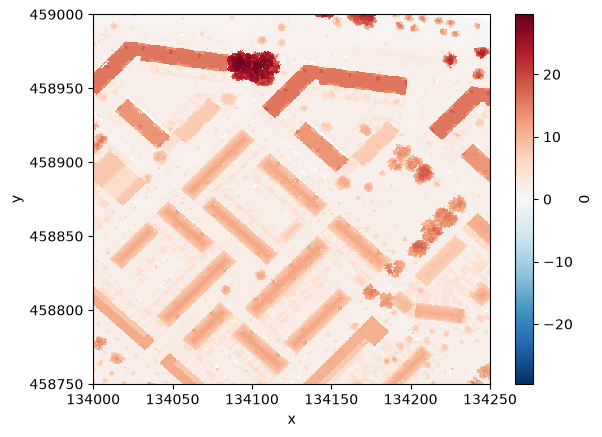

In [7]:
ds["0"][0:500, 0:500].plot.imshow()